<a href="https://colab.research.google.com/github/GabrielaTranslite/Sentiment_Analysis_Video_Games/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [306]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [307]:
# Reading the reviews file

print(f"File size: {os.path.getsize('steam_reviews_3274580.csv') / 1024:.0f} KB")

reviews = pd.read_csv('steam_reviews_3274580.csv', on_bad_lines='skip')
print(f"No of reviews: {len(reviews)}")


File size: 2356 KB
No of reviews: 5268


In [308]:
reviews.dtypes

review_id                int64
appid                    int64
author_steamid           int64
voted_up                  bool
votes_up                 int64
votes_funny              int64
review_text                str
timestamp_created        int64
publish_date               str
hours_on_record        float64
weighted_vote_score    float64
comment_count            int64
dtype: object

In [309]:
reviews.head()

,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count
0,227214755,3274580,76561198126302244,True,0,0,ok,1780643526,2026-06-05,512.93,0.50000,0
1,227173990,3274580,76561198069792288,True,0,0,I don't understand people....,1780595391,2026-06-04,59.97,0.50000,0
2,227077952,3274580,76561198389635009,True,0,0,Awesome game! I am looking...,1780484019,2026-06-03,4.37,0.50000,0
3,227046650,3274580,76561198060971315,True,1,0,I know this game has been ...,1780438119,2026-06-02,33.47,0.52381,0
4,227036499,3274580,76561198032581809,False,6,1,The game seems to just ran...,1780428223,2026-06-02,23.02,0.57529,0


Since as I discovered later, in the dataset there are some reviews in a different language than English (including Latin), I am adding a language detection step to drop non-English reviews.

In [310]:
from langdetect import detect, LangDetectException
from langdetect import DetectorFactory
DetectorFactory.seed = 42

def get_language(text):
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

reviews['language'] = reviews['review_text'].apply(get_language)
print(reviews['language'].value_counts())

language
en         4628
so          114
unknown      79
de           55
af           40
no           38
tl           35
ro           32
cy           26
es           25
it           24
ca           22
pl           18
tr           18
id           13
da           13
pt           10
fr            9
hu            8
nl            8
sl            8
sk            7
et            6
sw            5
sq            4
hr            4
vi            4
lt            3
zh-cn         3
ru            2
ar            2
th            2
ko            1
fi            1
sv            1
Name: count, dtype: int64


The amount of different languages surprised me, after going through all the languages, I decided to remove German, Polish, Chinese, Spanish and Romanian. The last one actually caught some Latin reviews present in the dataset. Some extra Latin reviews were present in Catalan, Portuguese and Italian, I will remove them manually. Langdetect had problems with shorter reviews, but I am going to drop them anyway one of the following steps.

In [311]:


print(reviews[reviews['language'] == 'unknown']['review_text'].head(100))

20          .
26          ,
110      7/10
289      👍👍👍👍
355       NaN
        ...  
4771        !
4851    +++++
5079     9/10
5199     6/10
5201        ‎
Name: review_text, Length: 79, dtype: str


In [312]:
# Dropping certain languages
reviews = reviews[~reviews['language'].isin(['zh-cn', 'de', 'pl', 'es', 'ro'])].copy()

# Dropping rows detected as non-English language
reviews_to_drop = reviews[reviews.index.isin([3565, 4397, 3812, 3820, 4833, 2249, 3994, 5212, 5256, 1687, 204, 715, 2060, 5255])]
print("Dropping the following reviews detected as non-English:")
print(reviews_to_drop[['review_text', 'language']])
reviews = reviews.drop(index=[3565, 4397, 3812, 3820, 4833, 2249, 3994, 5212, 5256, 1687, 204, 715, 2060, 5255])


Dropping the following reviews detected as non-English:
                        review_text language
204               Veni, vidi, vici.       it
715        Sono pazzi questi romani       it
1687  Akhirnya ada game Ubilembu...       id
2060          Barbarus ante portas!       pt
2249  Incroyable, pratiquement p...       fr
3565  Vini Vidi Vici: J’vais y’a...       nl
3812  Komplexná budovateľská str...       sk
3820                    Ave Caesar!       tr
3994  Recensio Anno 117 ab Homin...       ca
4397  Anno 117 is precies wat ik...       nl
4833      tout bonnement incroyable       fr
5212  Optimus ludus ANNO umquam ...       ca
5255  Praeter mutos comites meos...       pt
5256         Audentes fortuna iuvat       ca


In [313]:
# Removing empty reviews
reviews = reviews[reviews['review_text'].str.strip() != '']

In [314]:
# Checking for NaN values in 'review_text' column
print("NaN values in 'review_text' column:", reviews['review_text'].isna().sum())

NaN values in 'review_text' column: 22


In [315]:
# Dropping reviews with NaN in 'review_text'
reviews = reviews.dropna(subset=['review_text'])


In [316]:
# Number of reviews
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 5098


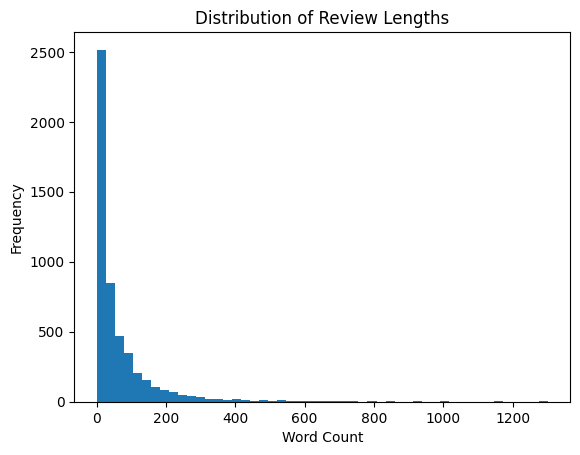

In [317]:
# Review lengths
reviews['word_count'] = reviews['review_text'].str.split().str.len()
plt.hist(reviews['word_count'], bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [318]:
# Removing reviews shorter than 3 words
reviews = reviews[reviews['word_count'] >= 3]

In [319]:
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 4623


In [320]:
# Checking for review_id duplicates in the dataset
reviews.duplicated(subset=['review_id']).sum()

# No duplicates found

np.int64(0)

In [321]:
# Converting columns
reviews['publish_date'] = pd.to_datetime(reviews['publish_date'])
reviews['voted_up'] = reviews['voted_up'].astype(int) # Changing True/False > 1/0
reviews.info()


<class 'pandas.DataFrame'>
Index: 4623 entries, 1 to 5267
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            4623 non-null   int64         
 1   appid                4623 non-null   int64         
 2   author_steamid       4623 non-null   int64         
 3   voted_up             4623 non-null   int64         
 4   votes_up             4623 non-null   int64         
 5   votes_funny          4623 non-null   int64         
 6   review_text          4623 non-null   str           
 7   timestamp_created    4623 non-null   int64         
 8   publish_date         4623 non-null   datetime64[us]
 9   hours_on_record      4623 non-null   float64       
 10  weighted_vote_score  4623 non-null   float64       
 11  comment_count        4623 non-null   int64         
 12  language             4623 non-null   str           
 13  word_count           4623 non-null   int64       

In [322]:
# Checking the min publish dates
reviews['publish_date'].min()

# The first review was published on 2025-11-12, that is on the release date of the game, so there are no reviews published before the release date.

Timestamp('2025-11-12 00:00:00')

In [323]:
# Checking the max publish date
reviews['publish_date'].max()

Timestamp('2026-06-04 00:00:00')

In [324]:
# Distribution of positive and negative reviews
print(reviews['voted_up'].value_counts(normalize=True))

# The dataset is imbalanced, with 63% positive reviews and 37% negative reviews. 


voted_up
1    0.622972
0    0.377028
Name: proportion, dtype: float64


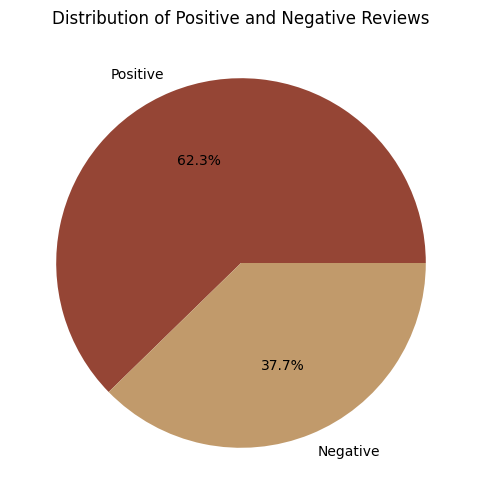

In [325]:
# Positive/negative reviews - pie chart
plt.figure(figsize=(6, 6))
plt.pie(reviews['voted_up'].value_counts(),
        labels=['Positive', 'Negative'],
        autopct='%1.1f%%',
        colors=['#954535', '#C19A6B'])
plt.title('Distribution of Positive and Negative Reviews')
plt.show()

*Adding patch releases dates*

One of the goals of my analysis is to check how the release of patches and announcements of new content influences the sentiment of players. Therefore I scraped the necessary data from Anno Pax Romana official website using Claude.

In [326]:
patch_dates = pd.read_csv('anno_117_pax_romana_patches.csv')
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Lau...,Game released on PC / PS5 ...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to f...
2,2025-12-09,1.3 (notes),Patch Notes,Patch 1.3 Notes Published,Official patch notes for v...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and ...
4,2026-01-28,1.3.2 (notes),Patch Notes,Patch 1.3.2 Notes Published,Official patch notes for v...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the ...
6,2026-02-18,1.4 (notes),Patch Notes,Patch 1.4 Notes Published,Full patch notes for versi...
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mos...,Patch 1.4 adds support for...
8,2026-03-05,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with ra...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and ...


In [327]:
# Converting patch release dates to datetime
patch_dates['Date'] = pd.to_datetime(patch_dates['Date'])

# Dropping the rows with patch notes publication dates, as they are not relevant for the analysis
patch_dates = patch_dates[~patch_dates['Title'].str.contains('notes', case=False)]
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Lau...,Game released on PC / PS5 ...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to f...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and ...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the ...
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mos...,Patch 1.4 adds support for...
8,2026-03-05,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with ra...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and ...
11,2026-04-30,1.5,Major Patch + DLC,Patch 1.5 + Prophecies of ...,First paid DLC for Anno 11...
12,2026-05-01,1.5 Hotfix,Hotfix,Update 1.5 HotFix (PC),PC hotfix released fixing ...
13,2026-05-05,NaN,Announcement,Upcoming Patches - Message...,Team acknowledged issues w...


In [328]:
# Adding specific periods between patch releases and announcements to table
reviews['period'] = reviews.apply(lambda row:
    '1.2' if row['publish_date'] < pd.Timestamp('2025-11-18') else
    '1.2 Hotfix' if row['publish_date'] < pd.Timestamp('2025-12-16') else
    '1.3' if row['publish_date'] < pd.Timestamp('2026-01-29') and row['publish_date'] >= pd.Timestamp('2025-12-16') else
    '1.3.2' if row['publish_date'] < pd.Timestamp('2026-02-19') and row['publish_date'] >= pd.Timestamp('2026-01-29') else
    '1.4 + Cosmetic DLC' if row['publish_date'] < pd.Timestamp('2026-03-05') and row['publish_date'] >= pd.Timestamp('2026-02-19') else
    '1.4.1' if row['publish_date'] < pd.Timestamp('2026-04-22') and row['publish_date'] >= pd.Timestamp('2026-03-05') else
    'Release Delay' if row['publish_date'] < pd.Timestamp('2026-04-30') and row['publish_date'] >= pd.Timestamp('2026-04-22') else
    '1.5 + Paid DLC + Hotfix' if row['publish_date'] < pd.Timestamp('2026-05-11') and row['publish_date'] >= pd.Timestamp('2026-04-30') else
    '1.5.1' if row['publish_date'] < pd.Timestamp('2026-05-28') and row['publish_date'] >= pd.Timestamp('2026-05-11') else
    '1.5.2', axis=1)

period_order = [
    '1.2', '1.2 Hotfix', '1.3', '1.3.2',
    '1.4 + Cosmetic DLC', '1.4.1', 'Release Delay',
    '1.5 + Paid DLC + Hotfix', '1.5.1', '1.5.2'
]
reviews['period'] = pd.Categorical(reviews['period'], categories=period_order, ordered=True)

reviews.tail()


,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count,language,word_count,period
5262,209074228,3274580,76561197960711140,1,0,0,Basically poops on the lik...,1762990994,2025-11-12,0.48,0.469799,0,en,19,1.2
5263,209074198,3274580,76561198041549155,0,0,0,Performance has improved s...,1762990969,2025-11-12,8.00,0.500000,0,en,166,1.2
5264,209074064,3274580,76561198144246893,0,0,0,"Mediocre graphics, art, UI...",1762990841,2025-11-12,3.73,0.500000,0,en,69,1.2
5266,209072424,3274580,76561199492495065,1,0,0,Make sure to update nVidia...,1762989478,2025-11-12,7.50,0.417803,2,en,152,1.2
5267,209072379,3274580,76561197972252273,1,0,0,GOTY Downsides: - The UI ...,1762989440,2025-11-12,6.48,0.500000,0,en,69,1.2


In [329]:
# Average score and number of reviews per period
period_summary = reviews.groupby('period').agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
)

print(period_summary) # The distribution is slightly uneven, which may affect the performance of text mining models

                         avg_score  review_count
period                                          
1.2                       0.602587          1701
1.2 Hotfix                0.684146          1621
1.3                       0.595978           547
1.3.2                     0.550725           138
1.4 + Cosmetic DLC        0.418605           129
1.4.1                     0.586466           266
Release Delay             0.578947            38
1.5 + Paid DLC + Hotfix   0.576923            78
1.5.1                     0.602410            83
1.5.2                     0.772727            22


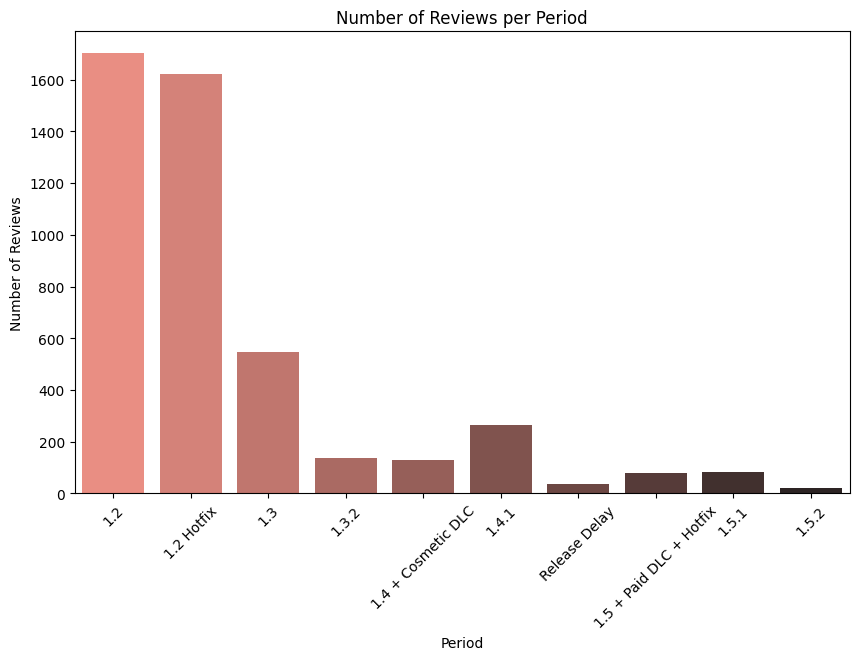

In [330]:
# Chart with number of reviews per period
plt.figure(figsize=(10, 6))
sns.barplot(x=period_summary.index, y=period_summary['review_count'], palette='dark:salmon_r')
plt.title('Number of Reviews per Period')
plt.xlabel('Period')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

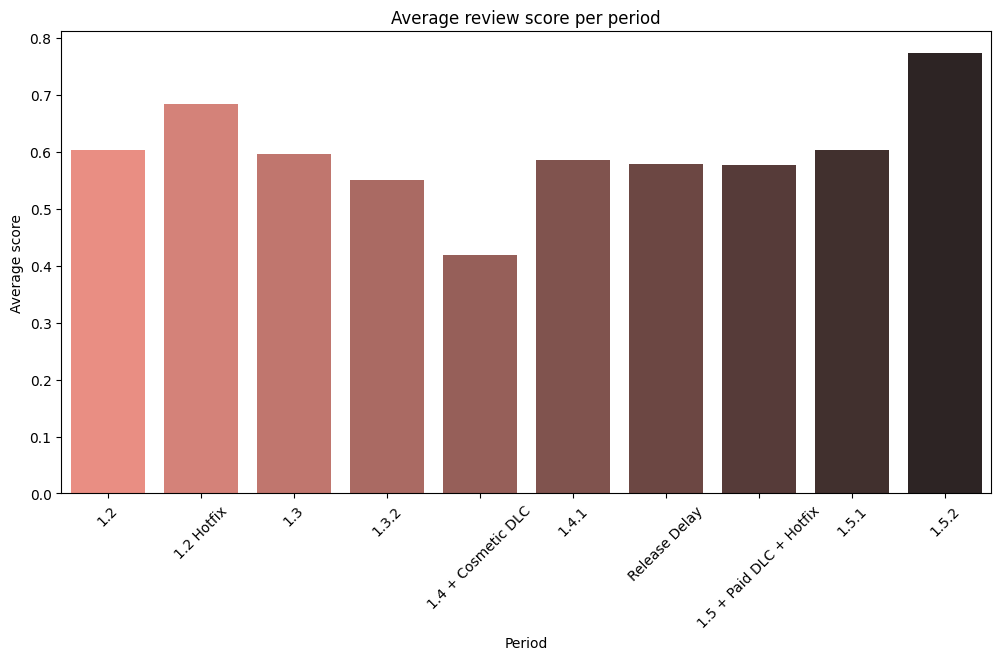

In [331]:
# Comparing the average review scores per period

# Average review score and number of reviews per period
period_summary = reviews.groupby('period').agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
)

plt.figure(figsize=(12, 6))
sns.barplot(x='period', y='avg_score', data=period_summary, palette='dark:salmon_r')
plt.title('Average review score per period')
plt.xlabel('Period')
plt.ylabel('Average score')
plt.xticks(rotation=45)
plt.show()

As we can see from the Steam data, the introduction of Hotfixes and DLCs seem to bring an increase of game scores. Directly after the release, Anno Pax Romana reached an average score of 0.6 which increased to 0.7 after the release of a hotfix. It suggests that there was some initial problem with the game. Hopefully, sentiment analysis will help us discover the exact problem. The average score dropped with time with the lowest score after the release of version 1.4 and Cosmetic DLC, but started to bounce back after the release of patch 1.4.1. Later, it again increased after the first paid DLC and another hotfix was released, with the peak at 1.5.2. The 1.5.2 period covers only 7 days and 22 reviews, so its high average score should be treated with caution."

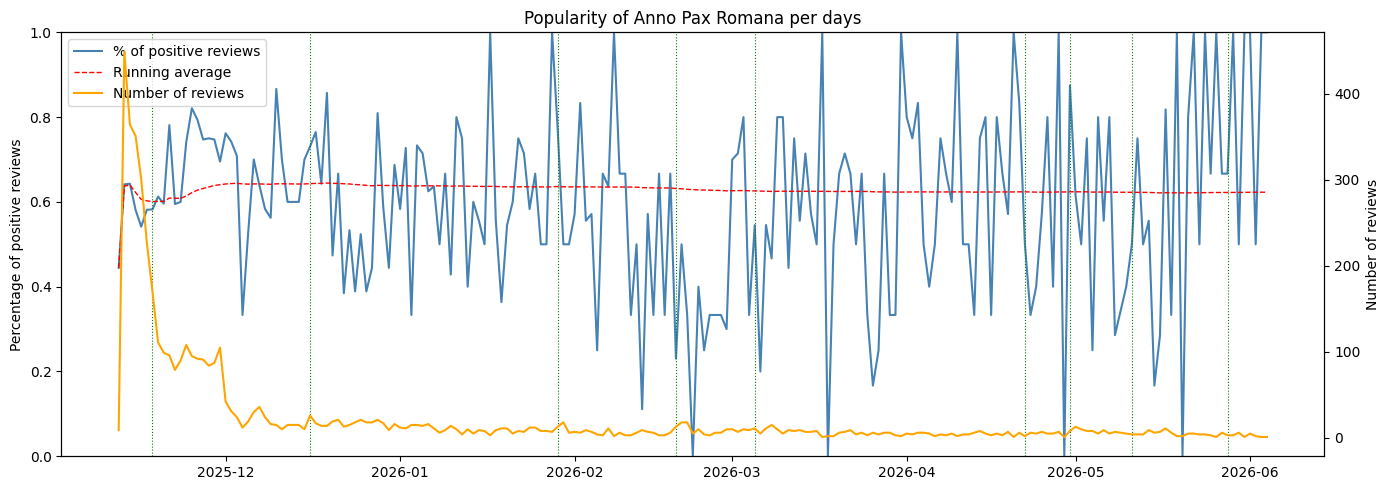

In [332]:
# Score mean and number of reviews per day
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Running (cumulative) average up to each date
daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['review_count'],
         color = 'orange',
         label = 'Number of reviews')
ax2.set_ylabel('Number of reviews')

# Deriving period boundaries from the reviews data (first date of each period except the first)
period_boundaries = (
    reviews.groupby('period', observed=True)['publish_date']
    .min()
    .iloc[1:]
    .values
)

# Running average line
ax1.plot(daily['publish_date'],
         daily['running_avg'],
         color='red', linestyle='--', linewidth=1,
         label='Running average')

# Vertical lines exactly at period boundaries
for d in period_boundaries:
    ax1.axvline(d, color='green', linestyle=':', linewidth=0.8)

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Popularity of Anno Pax Romana per days')
fig.tight_layout()
plt.show()


The chart above shows the number of reviews and percentage of positive reviews. Interestingly, Anno Pax Romana was not a victim of the so called review bombing, despite the less than perfect sentiment towards Ubisoft that is the parent company of the studio releasing the analysed game.

## Sentiment Analysis using VADER algorithm

VADER algorithm was designed to analyze the sentiment of social media texts, therefore it may be applicable to game reviews, which share characteristics with social media such as informal language and mixed sentiment

In [333]:
# Defining a cleaning function for VADER sentiment analysis

def clean_for_vader(text):
    text = re.sub(r'http\S+', '', text)   # only links
    return text.strip()

reviews['vader_text'] = reviews['review_text'].apply(clean_for_vader)


In [334]:
# Definying a cleaning function for other text mining models

def clean_text(text):
    text = text.lower()                          # convert to lowercase
    text = re.sub(r'http\S+', '', text)          # removing links
    text = re.sub(r'[^\w\s]', '', text)          # removing punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # removing multiple spaces
    return text

reviews['clean_text'] = reviews['review_text'].apply(clean_text)

In [335]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
reviews['sentiment_score'] = reviews['vader_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label'] = reviews['sentiment_score'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [336]:
# Checking the results with a classification report

from sklearn.metrics import classification_report

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label']
))

              precision    recall  f1-score   support

           0       0.71      0.51      0.59      1743
           1       0.75      0.87      0.80      2880

    accuracy                           0.74      4623
   macro avg       0.73      0.69      0.70      4623
weighted avg       0.73      0.74      0.73      4623



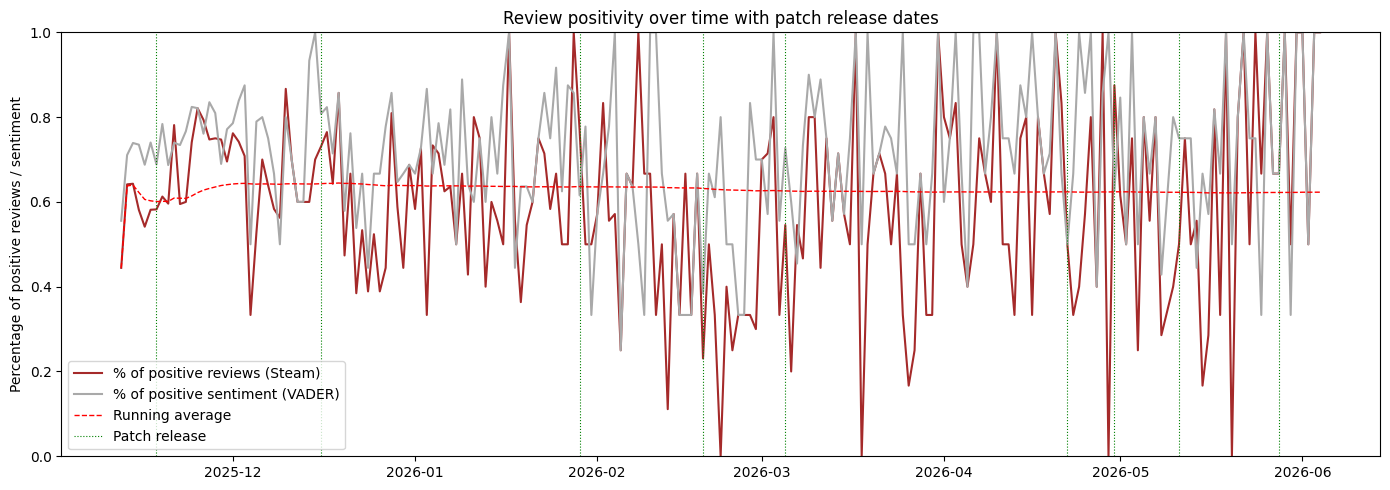

In [337]:
# Chart with patch release dates and VADER sentiment


daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score=('voted_up', 'mean'),
    avg_sentiment=('sentiment_label', 'mean'),
    review_count=('voted_up', 'count')
).reset_index()

daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Deriving period boundaries from the reviews data (first date of each period except the first)
period_boundaries = (
    reviews.groupby('period', observed=True)['publish_date']
    .min()
    .iloc[1:]
    .values
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(daily['publish_date'], daily['avg_score'],
         color='brown', label='% of positive reviews (Steam)')
ax1.plot(daily['publish_date'], daily['avg_sentiment'],
         color='darkgrey', label='% of positive sentiment (VADER)')
ax1.plot(daily['publish_date'], daily['running_avg'],
         color='red', linestyle='--', linewidth=1, label='Running average')
ax1.set_ylabel('Percentage of positive reviews / sentiment')
ax1.set_ylim(0, 1)

# Vertical lines exactly at period boundaries
for d in period_boundaries:
    ax1.axvline(d, color='green', linestyle=':', linewidth=0.8)

from matplotlib.lines import Line2D
vline_handle = Line2D([0], [0], color='green', linestyle=':', linewidth=0.8, label='Patch release')
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines + [vline_handle], labels + ['Patch release'], loc='lower left')

plt.title('Review positivity over time with patch release dates')
fig.tight_layout()
plt.show()

Both the classification report and the chart above show that VADER algorithm had some problems with distinguishing the correct sentiment. It's particularly visible in the "positive" peaks in March, April and May of 2026, where VADER overstated the sentiment. However, by the end of May, we can also see days where the VADER algorithm have incorrectly classified some positive reviews as negative reviews. The overall score is quite good with accuracy of 74%.

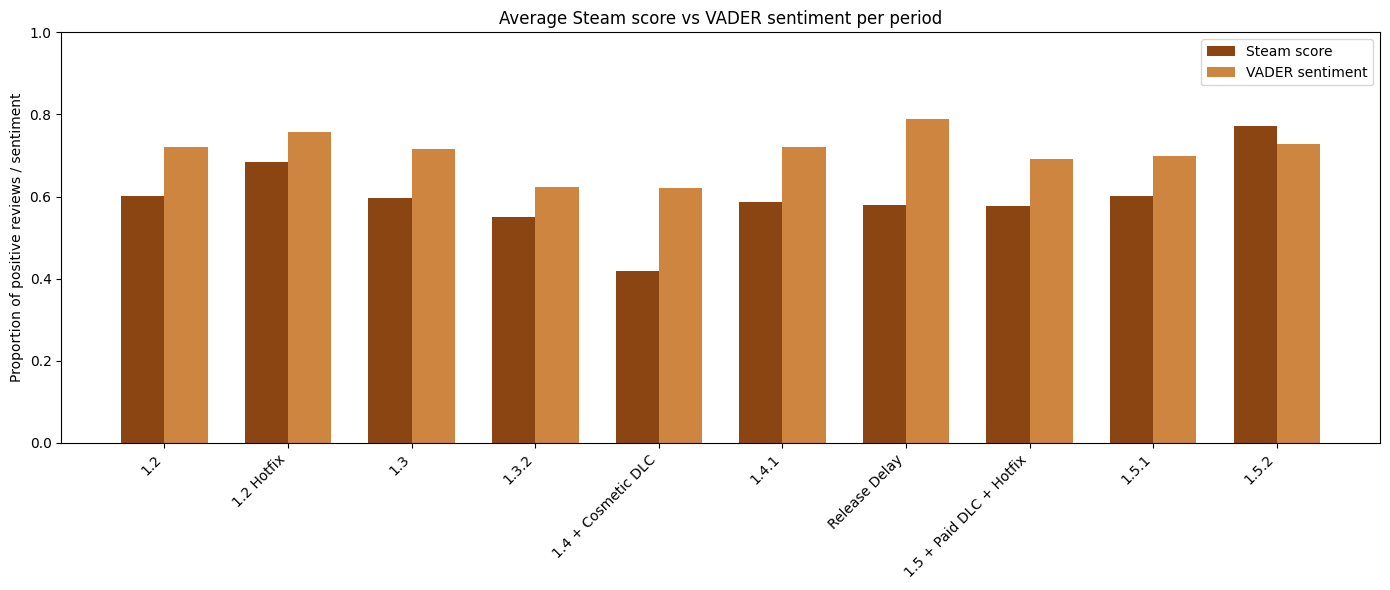

In [338]:
# Comparing the average sentiment scores per period (Steam vs VADER)
period_summary_combined = reviews.groupby("period", observed=True).agg(
    avg_steam_score=("voted_up", "mean"),
    avg_vader_label=("sentiment_label", "mean"),
    review_count=("voted_up", "count")
).reset_index()

x = np.arange(len(period_summary_combined))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, period_summary_combined["avg_steam_score"], width,
       label="Steam score", color="#8B4513")
ax.bar(x + width / 2, period_summary_combined["avg_vader_label"], width,
       label="VADER sentiment", color="#CD853F")

ax.set_xticks(x)
ax.set_xticklabels(period_summary_combined["period"], rotation=45, ha="right")
ax.set_ylabel("Proportion of positive reviews / sentiment")
ax.set_ylim(0, 1)
ax.set_title("Average Steam score vs VADER sentiment per period")
ax.legend()
plt.tight_layout()
plt.show()


In [339]:
# Checking the lowest and highest average sentiment scores and periods
print("Average sentiment scores per period (Steam):")
print(period_summary['avg_score'])
print("\nAverage sentiment scores per period (VADER):")
period_summary_sentiment = reviews.groupby('period').agg(
    avg_sentiment_label=('sentiment_label', 'mean'))
print(period_summary_sentiment['avg_sentiment_label'])


Average sentiment scores per period (Steam):
period
1.2                        0.602587
1.2 Hotfix                 0.684146
1.3                        0.595978
1.3.2                      0.550725
1.4 + Cosmetic DLC         0.418605
1.4.1                      0.586466
Release Delay              0.578947
1.5 + Paid DLC + Hotfix    0.576923
1.5.1                      0.602410
1.5.2                      0.772727
Name: avg_score, dtype: float64

Average sentiment scores per period (VADER):
period
1.2                        0.720752
1.2 Hotfix                 0.758174
1.3                        0.714808
1.3.2                      0.623188
1.4 + Cosmetic DLC         0.620155
1.4.1                      0.721805
Release Delay              0.789474
1.5 + Paid DLC + Hotfix    0.692308
1.5.1                      0.698795
1.5.2                      0.727273
Name: avg_sentiment_label, dtype: float64


## Lemmatization
Now, I am going to lemmatize the dataset in order to check whether this approach will improve the scores.

In [340]:
# Installing spaCy and downloading the English language model
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"],
               capture_output=True)

import spacy
nlp = spacy.load('en_core_web_sm')

# Lemmatization applied to vader_text (consistent with baseline VADER)
# spaCy handles POS tagging automatically
# Punctuation tokens are excluded when rejoining — they don't benefit from lemmatization
reviews['lemmatized_text'] = [
    ' '.join([token.lemma_ for token in doc
              if not token.is_punct and not token.is_space])
    for doc in nlp.pipe(reviews['vader_text'], batch_size=100)
]

# Running VADER on lemmatized text
sia_lemmatized = SentimentIntensityAnalyzer()
reviews['sentiment_score_lemmatized'] = reviews['lemmatized_text'].apply(
    lambda x: sia_lemmatized.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label_lemmatized'] = reviews['sentiment_score_lemmatized'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label_lemmatized']
))

              precision    recall  f1-score   support

           0       0.71      0.51      0.59      1743
           1       0.75      0.87      0.80      2880

    accuracy                           0.74      4623
   macro avg       0.73      0.69      0.70      4623
weighted avg       0.73      0.74      0.72      4623



Lemmatization was applied to vader_text — the same minimally pre-processed text used in the baseline VADER analysis — to ensure a fair comparison. SpaCy performs POS-aware lemmatization automatically, correctly reducing inflected verb and adjective forms. One side effect is that spaCy returns lemmas in lowercase, so capitalization signals (e.g. "GREAT") are lost in this version.

The results remain nearly identical to the baseline. This confirms that lemmatization does not benefit VADER: the algorithm already contains separate lexicon entries for inflected word forms ("loved", "loves", "loving"), so normalizing them to their base form removes information rather than adding it. The rest of the analysis continues with vader_text.

### Analysis of several incorrectly marked reviews

In [341]:
# Analyzing a sample of incorrectly classified reviews
incorrect = reviews[reviews['voted_up'].astype(int) != reviews['sentiment_label']]
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))

                        review_text  voted_up  sentiment_label
2532  It's Anno 1800 but in Rome...         0                1
1177  Not as good as Anno 1800 b...         1                0
203   ♥♥♥♥ all the haters, I lik...         1                0
4392  Most time spent in game is...         0                1
2713  MP is such a buggy mess it...         0                1
1384  There are a lot of strong ...         0                1
3014  Shortest campaign ever, I ...         0                1
5243  Finally it's here! After t...         0                1
955   Well around 100 hours in t...         0                1
720   Campaign is shorter than C...         1                0


In [342]:
pd.set_option('display.max_colwidth', None)
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             review_text  \
2532                                                        

Interestingly, it turns out that the sentiment analysis can sometimes be more truthful than the actual player score. Reviews no. 758 and 1812 show that the reviewers gave the game a vote up, but wrote a negative review. In turn, review no. 3213 is a list of wishes, so the algorithm didn't have clear signal. Similarly, reviews 3320 and 5123 were equally problematic due to use of sarcasm and idiomatic expressions that are difficult to evaluate by the algorithm.
Reviews 2726 and 4021 might give the algorithm mixed signals due to "compliment" + "but" structure.

## Using TF-IDF Analysis and Wordclouds for Top Terms Discovery

In [343]:
# TF-IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Defining custom stop words list by adding game-specific terms to the default English stop words
custom_stops = list(ENGLISH_STOP_WORDS) + ['anno', '1800', 'game', 'games', 'like', 'just', 'really', 'im', 'dont']

vec = TfidfVectorizer(stop_words=custom_stops, max_features=5000)
X = vec.fit_transform(reviews['clean_text'])

# Creating masks for positive and negative reviews (.values → numpy array, required for sparse indexing)
pos_mask = (reviews['voted_up'] == 1).values
neg_mask = (reviews['voted_up'] == 0).values

# Mean TF-IDF scores for each term in positive and negative reviews
mean_pos = np.asarray(X[pos_mask].mean(axis=0)).flatten()
mean_neg = np.asarray(X[neg_mask].mean(axis=0)).flatten()

terms = vec.get_feature_names_out()

# Top terms characteristic for positive reviews
top_pos = sorted(zip(terms, mean_pos), key=lambda x: x[1], reverse=True)[:20]
print("Top terms for positive reviews:")
for term, score in top_pos:
    print(f"{term}: {score}")




Top terms for positive reviews:
good: 0.04941154291308922
great: 0.04765870095879307
fun: 0.03131952225647169
love: 0.027778523851444515
city: 0.024695032835713525
far: 0.023763513678627574
new: 0.022165293520534535
best: 0.02123949905595439
time: 0.019497175604013633
play: 0.017689882036315864
series: 0.01747301690882565
campaign: 0.01681032623219059
better: 0.016801132942767742
roman: 0.016526191637804596
hours: 0.01611342738592046
building: 0.014937316078033783
played: 0.014576543967254994
builder: 0.014559253466405046
beautiful: 0.01375383412463779
nice: 0.013349938358809113


According to the TF-IDF analysis, it seems that Anno Pax Romana is perceived as a good or even great game by reviewers that gave it a vote up. It is also praised for the campaign, beautiful graphics, hours of play and the city building possibilities, which are characteristic for Anno series.

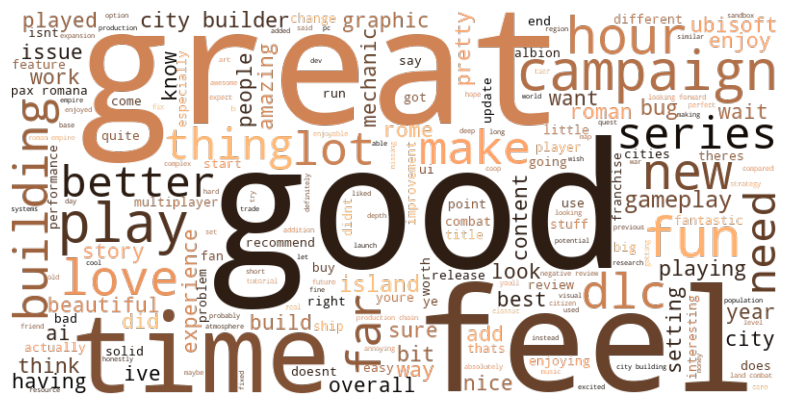

In [344]:
# Generating a WordCloud for positive reviews

from wordcloud import WordCloud
positive_text = ' '.join(reviews[reviews['voted_up'] == 1]['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color=None,
                      mode='RGBA',
                      stopwords=set(custom_stops),
                      colormap='copper').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [345]:
# Top terms characteristic for negative reviews
top_neg = sorted(zip(terms, mean_neg), key=lambda x: x[1], reverse=True)[:20]
print("\nTop terms for negative reviews:")
for term, score in top_neg:
    print(f"{term}: {score}")


Top terms for negative reviews:
ubisoft: 0.03645436179589777
ai: 0.028146844941181033
multiplayer: 0.02683632841182271
campaign: 0.02643205784629388
play: 0.02525212719192431
feels: 0.019772037963733197
time: 0.016651396397541606
bad: 0.01564196730836149
better: 0.015250848183692906
good: 0.015148170518014325
buy: 0.01514493457703663
hours: 0.015068164338932629
doesnt: 0.014218735702635465
release: 0.013456221295898123
connect: 0.013319428329311718
unfinished: 0.013218169349748695
work: 0.01314054883343538
fix: 0.01311217142136563
dlc: 0.013001027296170213
bugs: 0.012724248264857404


In turn, reviews that do not recommend the game have mainly negative connotations with Ubisoft company, which has admittedly bad press due to several failures of their previous titles, such as Assassin's Creed Shadows, cancellation of Prince of Persia: The Sands of Time remake, mass layoffs and studio closures.
The presence of AI in negative reviews is also important insight for the game developers. It seems that players value human creativity and are unhappy with AI creations in the game, even if they speed up the development.
The third important aspect influencing negative opinion is the multiplayer mode which seemed to not work correctly at the time of release.

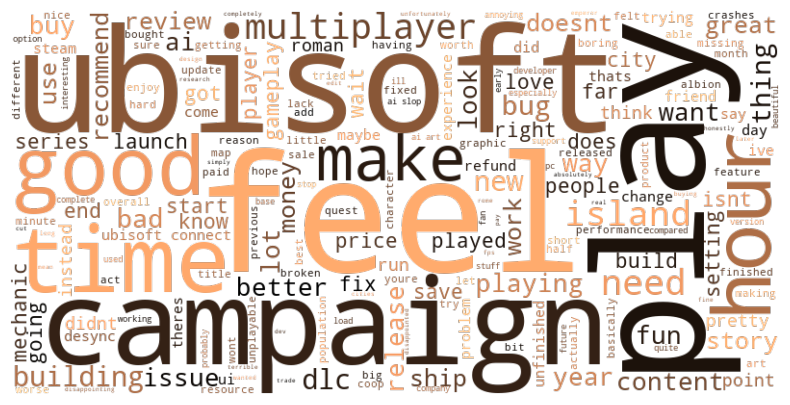

In [346]:
# Generating word clouds for negative reviews
negative_text = ' '.join(reviews[reviews['voted_up'] == 0]['clean_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color=None,
                      mode='RGBA',
                      stopwords=set(custom_stops),
                      colormap='copper').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.show()

## LDA Topic Modeling

This analysis was omitted in the course presentation due to potential lack of time.

In [347]:
# LDA topic modeling on all reviews

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vec = CountVectorizer(ngram_range=(1, 1), stop_words=custom_stops,
                      max_features=3000, min_df=10)
X = vec.fit_transform(reviews['clean_text'].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

feature_names = vec.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: roman, city, new, building, feels, 117, feel, build, production, buildings
Topics 2: dlc, multiplayer, content, great, good, new, wait, love, better, dlcs
Topics 3: great, good, campaign, fun, far, hours, city, played, time, play
Topics 4: ubisoft, play, connect, time, launcher, steam, save, hours, multiplayer, launch
Topics 5: ai, campaign, good, art, bad, story, people, ubisoft, use, time


In [348]:
# LDA topic modeling on positive reviews

vec_pos = CountVectorizer(ngram_range=(1, 2), stop_words=custom_stops, max_features=3000, min_df=10)
X_pos = vec_pos.fit_transform(reviews[reviews['voted_up'] == 1]['clean_text'].dropna())
lda_pos = LatentDirichletAllocation(n_components=5, random_state=42)
lda_pos.fit(X_pos) 
feature_names_pos = vec_pos.get_feature_names_out()
for i, topic in enumerate(lda_pos.components_):
    top_words = [feature_names_pos[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: city, roman, time, fun, hours, pax, builder, played, 117, city builder
Topics 2: new, buildings, production, building, combat, build, ai, better, good, campaign
Topics 3: good, new, series, roman, setting, far, performance, time, feels, love
Topics 4: good, play, ubisoft, city, great, time, love, people, bad, hours
Topics 5: great, campaign, fun, love, dlc, ai, forward, series, looking, amazing


In [349]:
# LDA topic modeling on negative reviews
vec_neg = CountVectorizer(ngram_range=(1, 2), stop_words=custom_stops, max_features=3000, min_df=10)
X_neg = vec_neg.fit_transform(reviews[reviews['voted_up'] == 0]['clean_text'].dropna())
lda_neg = LatentDirichletAllocation(n_components=5, random_state=42)
lda_neg.fit(X_neg)
feature_names_neg = vec_neg.get_feature_names_out()
for i, topic in enumerate(lda_neg.components_):
    top_words = [feature_names_neg[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: dlc, content, pass, ubisoft, release, year, money, paid, play, issues
Topics 2: ubisoft, multiplayer, play, connect, hours, time, ubisoft connect, work, desync, fix
Topics 3: city, new, island, build, buildings, need, feel, building, roman, islands
Topics 4: campaign, feels, story, hours, ends, feel, 117, short, better, price
Topics 5: ai, art, ubisoft, use, slop, artists, ai art, ai slop, generated, use ai


LDA topic modeling across all three review subsets reveals five consistent themes that align closely with the TF-IDF findings. In all reviews combined, the algorithm identified: Roman city-building mechanics, DLC and multiplayer content, positive gameplay experience, Ubisoft Connect technical issues, and the AI art controversy.

When applied separately to positive and negative reviews, the topics become more revealing. Positive reviews cluster around the enjoyment of city-building, the Roman setting, campaign quality, and anticipation of future DLC — suggesting that 
the core game loop and historical theme resonate well with satisfied players. Negative reviews, in contrast, surface four distinct pain points: dissatisfaction with DLC monetization and the year one pass, Ubisoft Connect launcher problems and 
multiplayer desync, criticism of the map and island-based design as insufficiently Roman, and strong opposition to the use of AI-generated art.

Notably, AI art appears in both positive and negative topic clusters, indicating that it is a divisive rather than uniformly negative issue. The campaign also appears across both sentiment groups, though in different contexts — praised for 
its quality in positive reviews, and criticised for its short length and price in negative ones.

## Top keywords in negative reviews per patch period

### TF-IDF

In [350]:
# Top 10 TF-IDF keywords in negative reviews per patch period
# TF-IDF is fit on ALL negative reviews so the vocabulary is shared across periods,
# making scores directly comparable column-to-column.

TOP_N = 10
MIN_REVIEWS = 5  # skip periods with too few negative reviews

neg = reviews[reviews['voted_up'] == 0].copy()

vec_per = TfidfVectorizer(stop_words=custom_stops, max_features=5000)
X_per = vec_per.fit_transform(neg['clean_text'])
terms_per = vec_per.get_feature_names_out()

results = {}
for period in neg['period'].cat.categories:
    mask = (neg['period'] == period).values
    if mask.sum() < MIN_REVIEWS:
        continue
    mean_scores = np.asarray(X_per[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:TOP_N]
    results[str(period)] = [terms_per[i] for i in top_idx]

keyword_table = pd.DataFrame(results, index=range(1, TOP_N + 1))
keyword_table.index.name = 'Rank'

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 20)
keyword_table


,1.2,1.2 Hotfix,1.3,1.3.2,1.4 + Cosmetic DLC,1.4.1,Release Delay,1.5 + Paid DLC + Hotfix,1.5.1,1.5.2
Rank,,,,,,,,,,
1,ai,campaign,campaign,finished,pass,ubisoft,pain,buy,ubisoft,deserves
2,ubisoft,ai,play,campaign,dlc,better,incomplete,better,play,business
3,multiplayer,ubisoft,multiplayer,content,year,hours,censoring,trajan,steam,expand
4,play,play,ubisoft,ubisoft,release,dlc,aspects,ubisoft,paid,city
5,campaign,multiplayer,hours,boring,paid,boring,bother,doesnt,fun,unknown
6,good,feels,fun,gets,season,feels,surprising,dlc,crashes,connect
7,desync,time,feels,isnt,content,content,build,play,launcher,rid
8,connect,bugs,time,close,years,buy,year,error,time,trying
9,art,way,better,recommend,ubisoft,pass,buy,liked,instead,hate


The TF-IDF keywords reveal a clear shift in player concerns over time. At launch (1.2), AI-generated art and multiplayer connectivity issues (desync, connect) dominate negative reviews. Multiplayer complaints persist through 1.3 and then fade, suggesting the issue was gradually resolved. From 1.4 onward, monetization language takes over — "pass", "dlc", "year", "paid", "season" — indicating that the Cosmetic DLC release shifted frustration from technical to commercial concerns. 
The Release Delay period stands out with terms like "censoring" and "incomplete", pointing to controversy around the DLC's content alongside frustration at the delay announcement. Technical issues (launcher, connect) resurface in later periods 
despite being less prominent mid-cycle.

### KeyBERT key phrases in negative reviews per patch period

In [351]:
from keybert import KeyBERT

from keybert import KeyBERT
kw_model = KeyBERT()

TOP_N = 10
MIN_REVIEWS = 5
MAX_REVIEWS = 50  # token limit cap for transformer model

neg = reviews[reviews['voted_up'] == 0].copy()

results_kb = {}
for period in neg['period'].cat.categories:
    period_neg = neg[neg['period'] == period]
    if len(period_neg) < MIN_REVIEWS:
        continue
    if len(period_neg) > MAX_REVIEWS:
        period_neg = period_neg.sample(n=MAX_REVIEWS, random_state=42)
    text = ' '.join(period_neg['clean_text'].dropna().tolist())
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 1),
        stop_words=custom_stops,
        top_n=TOP_N
    )
    results_kb[str(period)] = [phrase for phrase, score in keywords]

kb_table = pd.DataFrame(results_kb, index=range(1, TOP_N + 1))
kb_table.index.name = 'Rank'
pd.set_option('display.max_colwidth', 30)
kb_table


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,1.2,1.2 Hotfix,1.3,1.3.2,1.4 + Cosmetic DLC,1.4.1,Release Delay,1.5 + Paid DLC + Hotfix,1.5.1,1.5.2
Rank,,,,,,,,,,
1,ai,ubisoft,ubisoft,ubisoft,ubisoft,ubisoft,campaign,island,ubisoft,ubisoft
2,visuals,ubisofts,ubisofts,ubisofts,dlc,crashing,colonial,islands,launchinstead,ubishite
3,crashing,launcher,ubi,release,preorder,crashes,prologue,buildingonly,battlefield,city
4,crashes,ubi,ui,updates,dlcs,crash,factions,beginnerfriendly,ubislop,riots
5,studio,launch,fleet,map,romana,ubislop,romans,building,dlc,warning
6,gamebreaking,launches,fleets,editions,editionseason,build,rome,fleets,dlcs,frustrating
7,coopmp,desktop,menus,maps,buy,dlc,slavery,balancing,launch,safety
8,gameplay,fleet,setting,released,release,release,profiteering,franchise,gameplay,infernos
9,crash,login,annos,microsoft,roman,dlcs,antagonists,design,launched,bankrupt


KeyBERT surfaces more specific language than TF-IDF across most periods. Crash-related terms ("crashing", "crashes", "gamebreaking") appear prominently in 1.2 and again in 1.4.1, pointing to recurring stability problems that frequency-based TF-IDF partially obscures. The 1.2 Hotfix period highlights launcher-specific frustration ("launcher", "desktop", "login") rather than the generic "connect" captured by TF-IDF. In 1.3, gameplay mechanics draw criticism — "fleet", "menus", "ui", "settings" — suggesting interface and fleet management as pain points. The 1.5 + Paid DLC period shifts to gameplay 
design concerns: "islands", "building", "balancing", "logistics" indicate dissatisfaction with the DLC's depth and difficulty tuning rather than technical issues. Finally, the AI art slang evolves visibly across periods — from "ubislop" in 1.4.1 to "ubishite" in 1.5.2 — suggesting that community frustration with AI-generated content intensified and became more colourful over time.